In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint
from loguru import logger

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt
import hvplot.xarray
import panel

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

ngb = pamir.models.ngb

install(overflow=True)

In [268]:
def plot_profile(da, **props):

    x = da.values.T
    y = -da.depth.values

    if 'ax' not in props:
        fig, ax = plt.subplots(figsize=(4, 6))
    else:
        ax = props.pop('ax')
    
    ax.plot(x, y, **props)

    return ax

# Get data

In [236]:
s3_path = 's3://spi-pamir-cryogrid/pamir-MLpermafrost/data-output/ngboost-single_depth-cv_tuning/pamir-ngboost-ground_temp.zarr/'
ds = pamir.data.open_s3zarr(s3_path)
da = ds.yhat_ngboost
da_season_diff = da.diff(dim='season').isel(season=0, drop=True)

with ProgressBarDask():
    da_summer = ds.yhat_ngboost.sel(season='JAS', drop=True)
    da_winter = ds.yhat_ngboost.sel(season='JFM', drop=True)
    da_uncert_summer = ds.ystd_ngboost.sel(season='JAS', drop=True)
    da_uncert_winter = ds.ystd_ngboost.sel(season='JAS', drop=True)

In [293]:
s3_path = "s3://spi-pamir-cryogrid/pamir-MLpermafrost/data-inference/inference_variables-710w365s750e400n-100m.zarr/"
spatial = pamir.data.open_s3zarr(s3_path)
mask = (spatial.land_cover.interp_like(da) > 1)

# Compute ALT

In [238]:
with ProgressBarDask():
    da_summer_interp = (
        da_summer
        .interp(depth=np.arange(0, 10.1, 0.1), method='cubic')
        .bfill('depth')
        .persist())

    has_positive = (da_summer_interp > 0).any('depth')
    has_negative = (da_summer_interp < 0).any('depth')
    crosses_0 = (has_positive & has_negative)

    active_layer_thickness = (
        da_summer_interp
        .where(crosses_0)
        .pipe(abs)
        .idxmin('depth')
        .rename('active_layer_thickness')
        .assign_attrs(
            long_name='Active layer thickness',
            units='m')
        .persist())

  0%|          | 0/8210 [00:00<?, ?it/s]

  0%|          | 0/2880 [00:00<?, ?it/s]

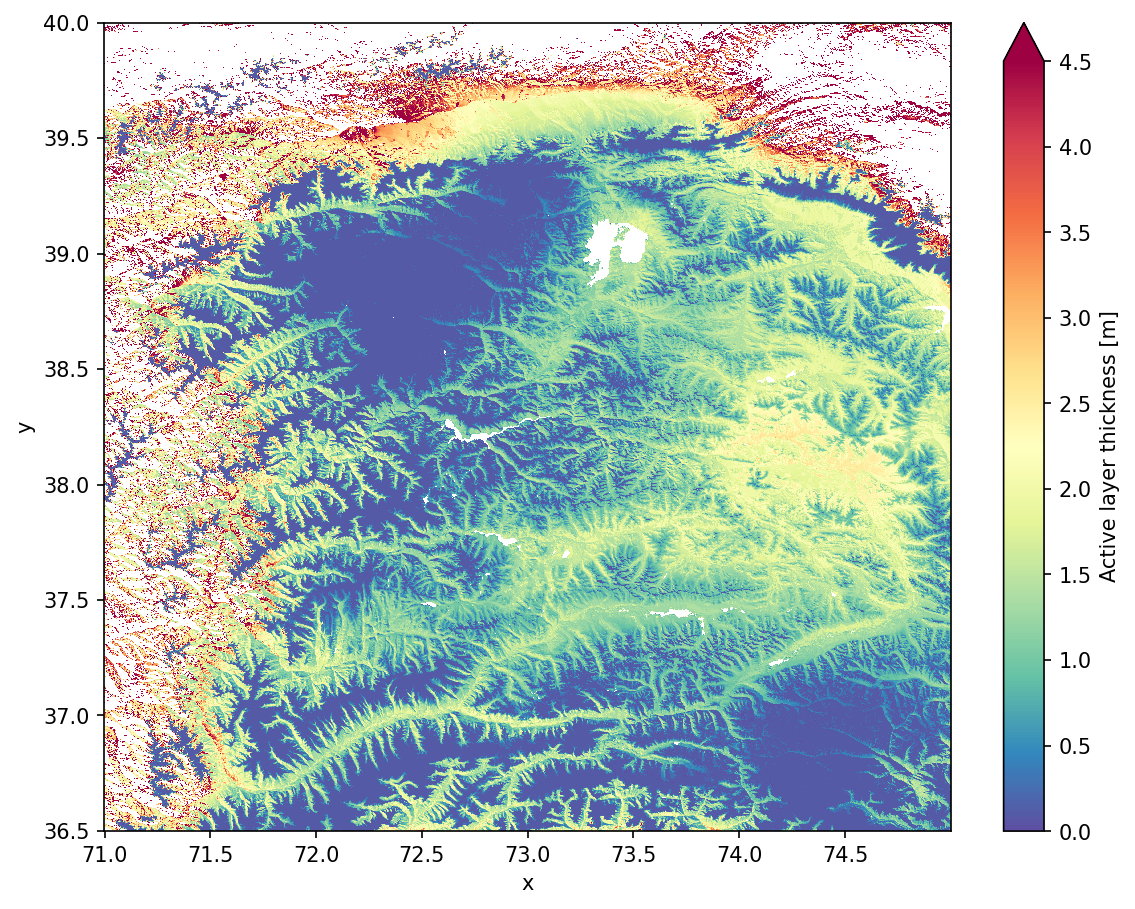

In [239]:
img = (
    active_layer_thickness
    .fillna(0.1)
    .where(has_negative & mask)
    .plot.imshow(vmin=0, vmax=4.5, size=7, aspect=1.3, cmap='Spectral_r')
)

img.figure.set_dpi(150)

<Axes: >

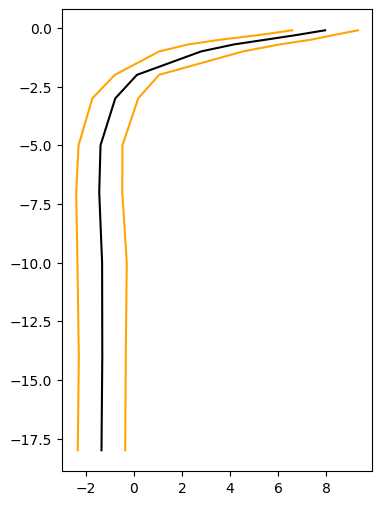

In [278]:
point = dict(y=39.5, x=72.75, method='nearest')

da = da_summer.sel(**point)
da_uncert = da_uncert_summer.sel(**point)

da_lower = da - da_uncert
da_upper = da + da_uncert

ax = da.pipe(plot_profile, color='k')
da_lower.pipe(plot_profile, color='orange', ax=ax)
da_upper.pipe(plot_profile, color='orange', ax=ax)

In [291]:
import joblib
from dask import dataframe as ddf

In [306]:
model = joblib.load('/home/renku/work/pamir-MLpermafrost/notebooks/4_ngboost_single_depth/ground_temp_JAS_3m.joblib_pkl')
names = model.feature_names_in_

X = pamir.data.s3_utils.open_s3_file(
    's3://spi-pamir-cryogrid/pamir-MLpermafrost/data-inference/inference_data-pamir_N180-matching_names-v20250916.parquet/',
    ddf.read_parquet)[names]

In [403]:
x0 = X.get_partition(3).compute().iloc[:5]
dist = model.pred_dist(x0)
dist.dist.cdf(0)

array([0.02729478, 0.02662643, 0.02662643, 0.03129594, 0.03447036])

In [397]:
# [k for k in dir(dist) if not k.startswith('_')]
# [k for k in dir(dist.dist) if not k.startswith('_')]

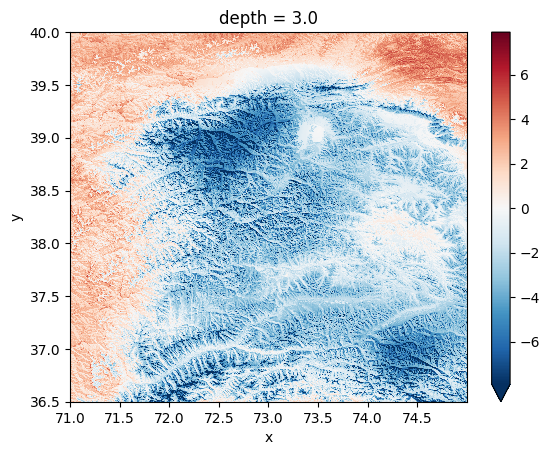

In [290]:
(da_summer[6] + da_uncert_summer[6]).plot.imshow(robust=True)

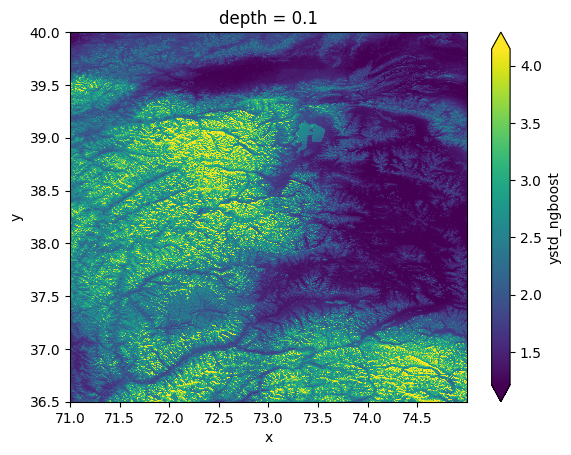

In [242]:
da_uncert_summer[0].plot.imshow(robust=True)